<a href="https://colab.research.google.com/github/gurubaleboina/image_segmentation_ADE20k/blob/main/Guru_ADE20K_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atrous Context against Plain Upsampling: DeepLabV3+ vs FCN on Four ADE20K Classes

## 1 | Environment

In [4]:
# Environment bootstrap for Google Colab or a local Jupyter kernel.
# Packages are installed through a guarded subprocess call, so re-running
# this cell is a no-op once the libraries are importable.
import importlib.util, subprocess, sys

def _ensure(pkgs):
    # pkgs maps import name -> pip spec; only what is missing gets installed.
    missing = [spec for name, spec in pkgs.items()
               if importlib.util.find_spec(name) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing],
                       check=True)

_ensure({
    "segmentation_models_pytorch": "segmentation-models-pytorch",
    "pycocotools": "pycocotools",
    "h5py": "h5py",
})

import json, random, zipfile
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from pycocotools import mask as mask_util
import segmentation_models_pytorch as smp
import torchvision
from PIL import Image

SEED = 7411
# One seed feeds python / numpy / torch so shuffling, the flip augmentation
# and weight initialisation all replay identically between sessions.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| running on", DEVICE)

torch 2.11.0+cu128 | running on cuda


## 2 | Configuration

In [5]:
# Every knob lives in one INI string parsed with the stdlib configparser.
# The typed getters (getint / getfloat) below keep the rest of the notebook
# free of loose magic numbers.
import configparser

INI_TEXT = """
[paths]
zip_name = RMDS_segmentation_dataset_ADE20K_350.zip
work_dir = ade_workdir
h5_name  = masks_350.h5
out_dir  = dlv3plus_bench

[task]
num_classes = 5
img_size    = 336

[train]
batch_size   = 7
lr_a         = 3e-4
lr_b         = 1e-3
weight_decay = 2e-4
num_workers  = 4
step_size    = 12
gamma        = 0.5
max_epochs   = 35
patience     = 9
"""

cfg = configparser.ConfigParser()
cfg.read_string(INI_TEXT)

NUM_CLASSES = cfg.getint("task", "num_classes")
IMG_SIZE    = cfg.getint("task", "img_size")
BATCH_SIZE  = cfg.getint("train", "batch_size")
OUT_DIR     = Path(cfg.get("paths", "out_dir"))
OUT_DIR.mkdir(exist_ok=True)

# ADE20K category ids -> compact training labels; 0 stays background.
CAT_TO_LABEL = {4: 1, 9: 2, 40: 3, 59: 4}
CLASS_NAMES  = ["background", "person", "car", "book", "airplane"]
# Dark2 supplies well separated hues; the same lookup is reused in every
# figure so a class keeps one colour throughout the notebook.
CLASS_COLORS = [plt.cm.Dark2(i) for i in range(NUM_CLASSES)]

for sec in cfg.sections():
    print(f"[{sec}] " + ", ".join(f"{k}={v}" for k, v in cfg[sec].items()))

[paths] zip_name=RMDS_segmentation_dataset_ADE20K_350.zip, work_dir=ade_workdir, h5_name=masks_350.h5, out_dir=dlv3plus_bench
[task] num_classes=5, img_size=336
[train] batch_size=7, lr_a=3e-4, lr_b=1e-3, weight_decay=2e-4, num_workers=4, step_size=12, gamma=0.5, max_epochs=35, patience=9


## 3 | Dataset Discovery

In [6]:
# Locate the assignment zip. On Colab it usually sits in /content (dragged
# into the file pane) or on a mounted Drive; locally it sits beside the
# notebook. Only a couple of likely spots are probed, then we fail loudly.
ZIP_NAME = cfg.get("paths", "zip_name")
WORK_DIR = Path(cfg.get("paths", "work_dir"))

_candidates = [
    Path("/content") / ZIP_NAME,
    Path("/content/drive/MyDrive") / ZIP_NAME,
    Path.cwd() / ZIP_NAME,
]
zip_path = next((p for p in _candidates if p.exists()), None)
if zip_path is None:
    probed = "\n  ".join(str(p) for p in _candidates)
    raise FileNotFoundError(
        f"{ZIP_NAME} was not found. Paths probed:\n  {probed}\n"
        "Copy the archive to one of these locations (or mount Drive) and rerun."
    )

if not WORK_DIR.exists():
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(WORK_DIR)
print("archive expanded under:", WORK_DIR)

def _find_split(name):
    # The zip may wrap everything in one extra folder; take the first match.
    # Ignore hidden macOS resource forks
    dirs = [p for p in sorted(WORK_DIR.rglob(name)) if p.is_dir() and "__MACOSX" not in p.parts]
    if not dirs:
        raise FileNotFoundError(f"split folder '{name}' missing inside {WORK_DIR}")
    return dirs[0]

TRAIN_DIR, VAL_DIR, TEST_DIR = (_find_split(n) for n in ("train", "val", "test"))

def _load_json(name):
    hits = [p for p in sorted(WORK_DIR.rglob(name)) if "__MACOSX" not in p.parts]
    if not hits:
        raise FileNotFoundError(f"{name} missing inside {WORK_DIR}")
    with open(hits[0]) as fh:
        return json.load(fh)

coco_train = _load_json("instances_train.json")
coco_val   = _load_json("instances_val.json")

def index_split(coco):
    # {image_id: {"file", "hw", "anns"}} keeping only the four target classes.
    rec = {im["id"]: {"file": im["file_name"],
                      "hw": (im["height"], im["width"]),
                      "anns": []}
           for im in coco["images"]}
    kept = 0
    for a in coco["annotations"]:
        if a["category_id"] in CAT_TO_LABEL:
            rec[a["image_id"]]["anns"].append(a)
            kept += 1
    return rec, kept

train_index, n_tr = index_split(coco_train)
val_index,   n_va = index_split(coco_val)

# Exclude any hidden files that start with .
test_images = [p for p in sorted(TEST_DIR.rglob("*.jpg")) + sorted(TEST_DIR.rglob("*.png")) if not p.name.startswith("._")]

def image_path(split_dir, file_name):
    # file_name may or may not carry a sub-folder prefix inside the zip.
    direct = split_dir / file_name
    if direct.exists():
        return direct
    # filter hidden mac files here as well just in case
    matches = [p for p in sorted(split_dir.rglob(Path(file_name).name)) if not p.name.startswith("._")]
    return matches[0]

print(f"images -> train {len(train_index)} | val {len(val_index)} | test {len(test_images)}")
print(f"annotations kept -> train {n_tr} | val {n_va}")

archive expanded under: ade_workdir
images -> train 350 | val 350 | test 30
annotations kept -> train 1941 | val 2351


## 4 | Mask Decoding Into HDF5

In [7]:
# Every COCO segmentation is decoded exactly once and the finished uint8
# label maps are persisted in a single gzip-compressed HDF5 store, keyed
# split/image_id. Training epochs then read ready-made masks instead of
# re-running pycocotools on each sample.
H5_PATH = WORK_DIR / cfg.get("paths", "h5_name")

def ann_to_binary(ann, hw):
    seg = ann["segmentation"]
    if isinstance(seg, list):                    # polygon list
        rle = mask_util.merge(mask_util.frPyObjects(seg, *hw))
    elif isinstance(seg.get("counts"), list):    # uncompressed RLE
        rle = mask_util.frPyObjects(seg, *hw)
    else:                                        # compressed RLE
        rle = seg
    return mask_util.decode(rle).astype(bool)

# Overlap rule: annotations are painted in DESCENDING category-id order
# (59 -> 40 -> 9 -> 4) and a later paint may only claim pixels that are
# still background. Airplane and book are the rarest classes here, so they
# are rasterised first and a far commoner person or car blob can never
# bury their few pixels. Tradeoff: where a person genuinely occludes a
# book, the disputed pixels are credited to the book - with so little
# book/airplane mass overall this costs less than losing rare classes.
PAINT_ORDER = sorted(CAT_TO_LABEL, reverse=True)

def compose_mask(rec):
    h, w = rec["hw"]
    canvas = np.zeros((h, w), dtype=np.uint8)
    for cid in PAINT_ORDER:
        lbl = CAT_TO_LABEL[cid]
        for ann in rec["anns"]:
            if ann["category_id"] != cid:
                continue
            m = ann_to_binary(ann, (h, w))
            canvas[m & (canvas == 0)] = lbl      # never overwrite earlier paint
    return canvas

if not H5_PATH.exists():
    with h5py.File(H5_PATH, "w") as h5:
        for split, index in (("train", train_index), ("val", val_index)):
            for img_id, rec in index.items():
                h5.create_dataset(f"{split}/{img_id}", data=compose_mask(rec),
                                  dtype="uint8", compression="gzip")

with h5py.File(H5_PATH, "r") as h5:
    n_masks = len(h5["train"]) + len(h5["val"])
print(f"HDF5 mask store ready: {H5_PATH.name} holding {n_masks} label maps")

HDF5 mask store ready: masks_350.h5 holding 700 label maps


## 5 | Exploratory Views

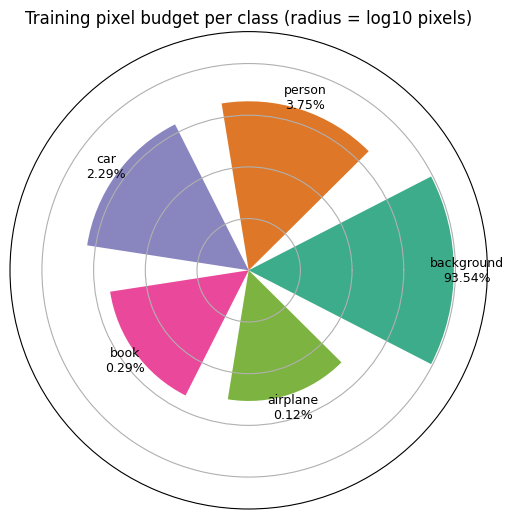

In [8]:
# View 1 - polar bars of the training pixel budget. Radius is log10 of the
# pixel count, which stops the giant background spoke from flattening the
# four foreground classes; the printed percentage is the raw linear share.
def pixel_counts(split):
    counts = np.zeros(NUM_CLASSES, dtype=np.int64)
    with h5py.File(H5_PATH, "r") as h5:
        for key in h5[split]:
            counts += np.bincount(h5[split][key][()].ravel(),
                                  minlength=NUM_CLASSES)
    return counts

train_px = pixel_counts("train")
val_px   = pixel_counts("val")

share = train_px / train_px.sum()
theta = np.linspace(0.0, 2 * np.pi, NUM_CLASSES, endpoint=False)
radii = np.log10(train_px + 1)

fig, ax = plt.subplots(figsize=(6.2, 6.2), subplot_kw={"projection": "polar"})
ax.bar(theta, radii, width=0.95, color=CLASS_COLORS, alpha=0.85)
for ang, r, name, s in zip(theta, radii, CLASS_NAMES, share):
    ax.text(ang, r + 0.5, f"{name}\n{s:.2%}", ha="center", va="center", fontsize=9)
ax.set_ylim(0, radii.max() + 1.3)
ax.set_yticklabels([])
ax.set_xticks([])
ax.set_title("Training pixel budget per class (radius = log10 pixels)")
plt.show()

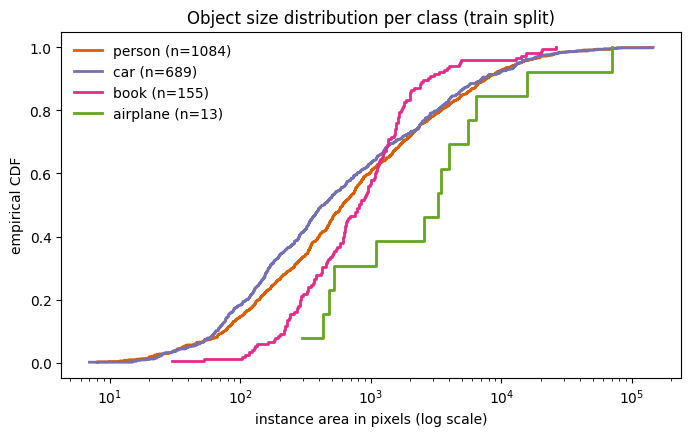

In [9]:
# View 2 - per-class ECDF of annotated instance areas on a log x axis.
# A curve hugging the left edge marks a class dominated by small objects,
# which is exactly where a 336 px input and coarse decoders lose IoU.
areas = {lbl: [] for lbl in range(1, NUM_CLASSES)}
for rec in train_index.values():
    for ann in rec["anns"]:
        areas[CAT_TO_LABEL[ann["category_id"]]].append(max(float(ann["area"]), 1.0))

fig, ax = plt.subplots(figsize=(8, 4.5))
for lbl in range(1, NUM_CLASSES):
    a = np.sort(np.asarray(areas[lbl], dtype=float))
    if a.size == 0:
        continue
    y = np.arange(1, a.size + 1) / a.size
    ax.step(a, y, where="post", linewidth=2, color=CLASS_COLORS[lbl],
            label=f"{CLASS_NAMES[lbl]} (n={a.size})")
ax.set_xscale("log")
ax.set_xlabel("instance area in pixels (log scale)")
ax.set_ylabel("empirical CDF")
ax.set_title("Object size distribution per class (train split)")
ax.legend(frameon=False)
plt.show()

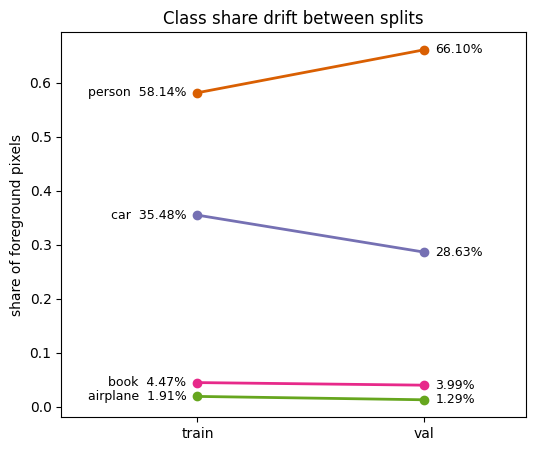

In [10]:
# View 3 - slope chart of each class's share of FOREGROUND pixels in the
# train column versus the val column. Nearly level lines mean the split is
# balanced and validation scores generalise; a steep line flags drift.
tr_share = train_px[1:] / train_px[1:].sum()
va_share = val_px[1:] / val_px[1:].sum()

fig, ax = plt.subplots(figsize=(6, 5))
for i, name in enumerate(CLASS_NAMES[1:], start=1):
    left, right = tr_share[i - 1], va_share[i - 1]
    ax.plot([0, 1], [left, right], marker="o", linewidth=2,
            color=CLASS_COLORS[i])
    ax.annotate(f"{name}  {left:.2%}", (0, left), xytext=(-8, 0),
                textcoords="offset points", ha="right", va="center", fontsize=9)
    ax.annotate(f"{right:.2%}", (1, right), xytext=(8, 0),
                textcoords="offset points", ha="left", va="center", fontsize=9)
ax.set_xlim(-0.6, 1.45)
ax.set_xticks([0, 1])
ax.set_xticklabels(["train", "val"])
ax.set_ylabel("share of foreground pixels")
ax.set_title("Class share drift between splits")
plt.show()

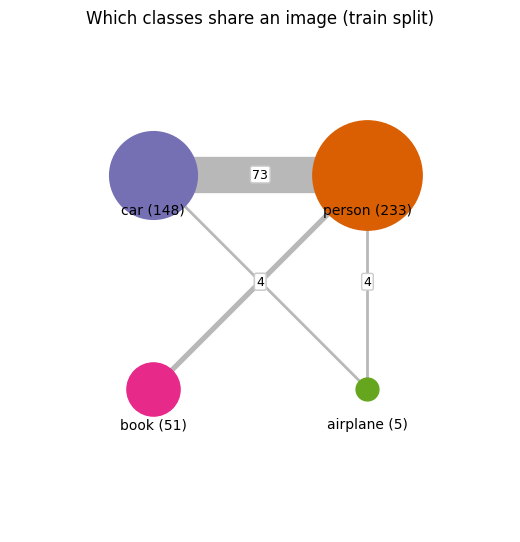

In [11]:
# View 4 - co-occurrence network. Node size scales with the number of
# training images containing the class; edge width with the number of
# images where both endpoints appear together. A heavy person-car edge
# means street context; an isolated airplane node means the model gets
# little co-occurring context to lean on for that class.
presence = {lbl: set() for lbl in range(1, NUM_CLASSES)}
for img_id, rec in train_index.items():
    for ann in rec["anns"]:
        presence[CAT_TO_LABEL[ann["category_id"]]].add(img_id)

labels = list(range(1, NUM_CLASSES))
pos_angle = np.linspace(0, 2 * np.pi, len(labels), endpoint=False) + np.pi / 4
xy = np.c_[np.cos(pos_angle), np.sin(pos_angle)]

fig, ax = plt.subplots(figsize=(6.5, 6.5))
for i in range(len(labels)):
    for j in range(i + 1, len(labels)):
        both = len(presence[labels[i]] & presence[labels[j]])
        if both == 0:
            continue
        ax.add_line(Line2D([xy[i, 0], xy[j, 0]], [xy[i, 1], xy[j, 1]],
                           linewidth=0.6 + 0.35 * both, color="0.65",
                           alpha=0.8, zorder=1))
        mx, my = (xy[i] + xy[j]) / 2
        ax.text(mx, my, str(both), fontsize=9, ha="center", va="center",
                bbox={"boxstyle": "round,pad=0.15", "fc": "white", "ec": "0.8"},
                zorder=3)
for i, lbl in enumerate(labels):
    n_img = len(presence[lbl])
    ax.scatter(xy[i, 0], xy[i, 1], s=140 + 26 * n_img,
               color=CLASS_COLORS[lbl], zorder=2)
    ax.text(xy[i, 0], xy[i, 1] - 0.26, f"{CLASS_NAMES[lbl]} ({n_img})",
            ha="center", fontsize=10)
ax.set_xlim(-1.65, 1.65)
ax.set_ylim(-1.65, 1.65)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Which classes share an image (train split)")
plt.show()

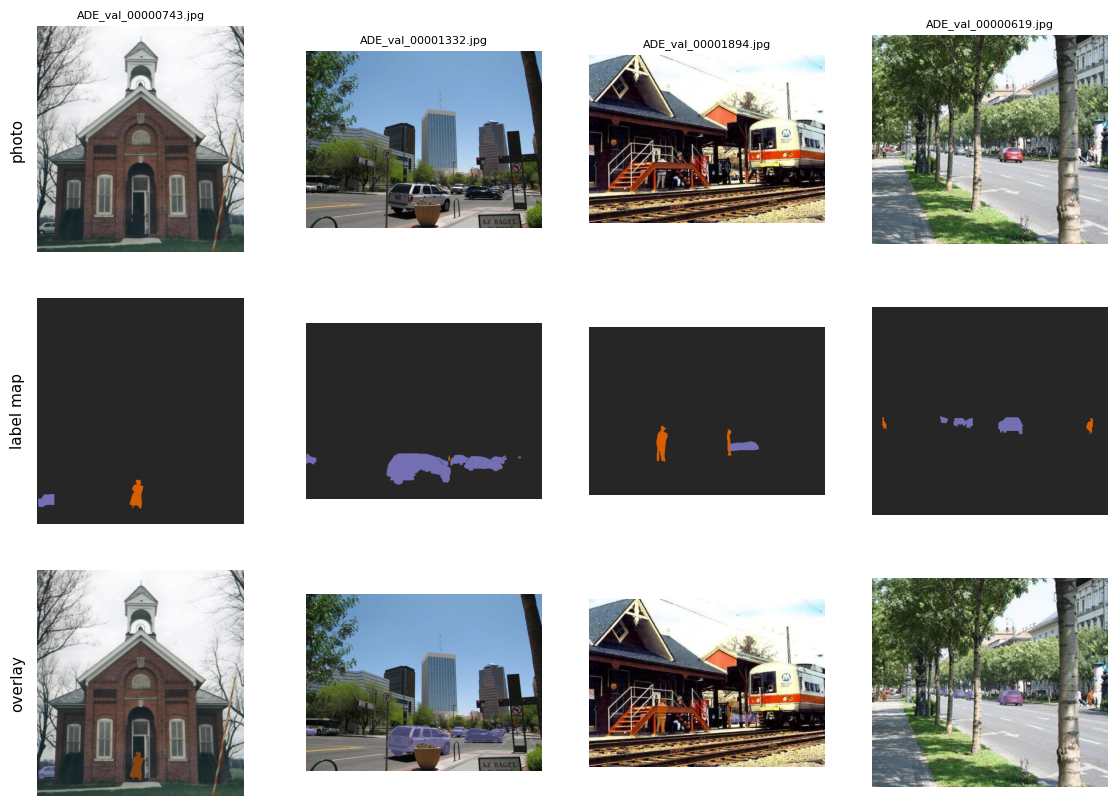

In [12]:
# View 5 - three-row gallery: photo / label map / tinted overlay. Samples
# are drawn from images holding at least two foreground classes, so the
# no-overwrite overlap rule from section 4 is actually visible.
rng = np.random.default_rng(SEED)
rich = [i for i, r in train_index.items()
        if len({CAT_TO_LABEL[a["category_id"]] for a in r["anns"]}) >= 2]
pool = rich if len(rich) >= 4 else list(train_index)
picks = [int(v) for v in rng.choice(np.asarray(pool), size=4, replace=False)]

def mask_rgb(mask):
    out = np.full((*mask.shape, 3), 0.15)
    for lbl in range(1, NUM_CLASSES):
        out[mask == lbl] = np.asarray(CLASS_COLORS[lbl][:3])
    return out

def tint(img, mask, alpha=0.55):
    out = img.astype(float) / 255.0
    for lbl in range(1, NUM_CLASSES):
        sel = mask == lbl
        out[sel] = (1 - alpha) * out[sel] + alpha * np.asarray(CLASS_COLORS[lbl][:3])
    return out

row_titles = ["photo", "label map", "overlay"]
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
with h5py.File(H5_PATH, "r") as h5:
    for col, img_id in enumerate(picks):
        rec = train_index[img_id]
        photo = np.asarray(Image.open(image_path(TRAIN_DIR, rec["file"])).convert("RGB"))
        mask = h5[f"train/{img_id}"][()]
        axes[0, col].imshow(photo)
        axes[1, col].imshow(mask_rgb(mask))
        axes[2, col].imshow(tint(photo, mask))
        axes[0, col].set_title(Path(rec["file"]).name, fontsize=8)
        for r in range(3):
            axes[r, col].axis("off")
for r, name in enumerate(row_titles):
    axes[r, 0].text(-0.06, 0.5, name, transform=axes[r, 0].transAxes,
                    rotation=90, ha="right", va="center", fontsize=11)
plt.show()

## 6 | Data Pipeline

In [13]:
# Reusable preprocessing tool: FramePrep bundles the resize + normalise
# maths once, and its prep_image() is later reused verbatim on raw test
# photos, so training and inference can never drift apart.
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

class FramePrep:
    def __init__(self, side):
        self.side = side

    def prep_image(self, pil_img):
        pil_img = pil_img.convert("RGB").resize((self.side, self.side),
                                                Image.BILINEAR)
        arr = np.asarray(pil_img, dtype=np.float32) / 255.0
        arr = (arr - IMAGENET_MEAN) / IMAGENET_STD
        return torch.from_numpy(arr.transpose(2, 0, 1))

    def prep_mask(self, mask_arr):
        # Nearest neighbour keeps labels categorical while resizing.
        pil_m = Image.fromarray(mask_arr).resize((self.side, self.side),
                                                 Image.NEAREST)
        return torch.from_numpy(np.asarray(pil_m).copy()).long()

class HdfSegPairs(Dataset):
    # Photos come from disk, masks from the shared HDF5 store. The h5
    # handle is opened lazily inside __getitem__ because handles must not
    # cross the DataLoader fork boundary - each worker gets its own.
    def __init__(self, split, index, split_dir, prep, jitter=False):
        self.split, self.index = split, index
        self.ids = sorted(index)
        self.split_dir, self.prep, self.jitter = split_dir, prep, jitter
        self._h5 = None

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, i):
        if self._h5 is None:
            self._h5 = h5py.File(H5_PATH, "r")
        img_id = self.ids[i]
        rec = self.index[img_id]
        pil = Image.open(image_path(self.split_dir, rec["file"]))
        mask = self._h5[f"{self.split}/{img_id}"][()]
        if self.jitter and random.random() < 0.5:
            # Horizontal flip is the one augmentation that is always
            # label-safe for these classes and costs nothing.
            pil = pil.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
            mask = mask[:, ::-1].copy()
        return self.prep.prep_image(pil), self.prep.prep_mask(mask)

prep = FramePrep(IMG_SIZE)
train_ds = HdfSegPairs("train", train_index, TRAIN_DIR, prep, jitter=True)
val_ds   = HdfSegPairs("val", val_index, VAL_DIR, prep)

NUM_WORKERS = cfg.getint("train", "num_workers")
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
print(f"loaders ready | train batches {len(train_loader)} | val batches {len(val_loader)}")

loaders ready | train batches 50 | val batches 50


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## 7 | Models And Loss Weights

In [14]:
# Class weights: w_c = log(1 + 1/freq_c), capped at 8.0. The log tames the
# otherwise explosive weight a near-absent class would receive under plain
# inverse frequency, while still steering the loss away from the trivial
# all-background solution; the cap bounds gradient noise on tiny classes.
freq = train_px / train_px.sum()
log_w = np.minimum(np.log1p(1.0 / np.maximum(freq, 1e-12)), 8.0)
CLASS_WEIGHTS = torch.tensor(log_w, dtype=torch.float32, device=DEVICE)
for name, w in zip(CLASS_NAMES, log_w):
    print(f"log weight  {name:<11}{w:6.3f}")

# Model A - DeepLabV3+ with a ResNet-50 ImageNet encoder, trained end to
# end. Its ASPP block samples context at several atrous rates and a light
# decoder re-injects low-level detail: the "atrous context" contender.
model_a = smp.DeepLabV3Plus(encoder_name="resnet50",
                            encoder_weights="imagenet",
                            classes=NUM_CLASSES).to(DEVICE)

# Model B - torchvision FCN-ResNet50 pretrained on COCO. The backbone is
# FROZEN in its entirety; only a freshly initialised 5-way 1x1 classifier
# convolution learns. FCN restores resolution with plain bilinear
# upsampling and has no atrous context module - the exact counterpoint.
fcn_w = torchvision.models.segmentation.FCN_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
model_b = torchvision.models.segmentation.fcn_resnet50(weights=fcn_w)
model_b.aux_classifier = None
model_b.classifier[4] = nn.Conv2d(512, NUM_CLASSES, kernel_size=1)
for p in model_b.parameters():
    p.requires_grad = False
for p in model_b.classifier[4].parameters():
    p.requires_grad = True
model_b = model_b.to(DEVICE)

def n_trainable(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f"trainable parameters | DeepLabV3+ {n_trainable(model_a):,} "
      f"| FCN head {n_trainable(model_b):,}")

log weight  background  0.727
log weight  person      3.319
log weight  car         3.799
log weight  book        5.851
log weight  airplane    6.700


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Downloading: "https://download.pytorch.org/models/fcn_resnet50_coco-1167a1af.pth" to /root/.cache/torch/hub/checkpoints/fcn_resnet50_coco-1167a1af.pth


100%|██████████| 135M/135M [00:00<00:00, 175MB/s]


trainable parameters | DeepLabV3+ 26,678,613 | FCN head 2,565


## 8 | Training

In [15]:
CRITERION = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)

def logits_of(model, x):
    # torchvision segmentation heads return an OrderedDict; smp a tensor.
    out = model(x)
    return out["out"] if isinstance(out, dict) else out

def crosstab_confusion(model, loader):
    # Confusion matrix from pandas.crosstab over stride-4 subsampled pixel
    # grids: every 4th row and column is plenty for stable IoU estimates
    # and shrinks the flattened arrays by ~16x.
    model.eval()
    gts, prs = [], []
    with torch.no_grad():
        for x, y in loader:
            pred = logits_of(model, x.to(DEVICE)).argmax(1).cpu()
            gts.append(y[:, ::4, ::4].reshape(-1).numpy())
            prs.append(pred[:, ::4, ::4].reshape(-1).numpy())
    tab = pd.crosstab(pd.Series(np.concatenate(gts), name="actual"),
                      pd.Series(np.concatenate(prs), name="predicted"))
    return tab.reindex(index=range(NUM_CLASSES),
                       columns=range(NUM_CLASSES), fill_value=0)

def scores_from_crosstab(tab):
    # Per-class IoU and Dice fall straight out of the crosstab margins.
    diag = np.diag(tab.values).astype(float)
    row = tab.values.sum(axis=1).astype(float)
    col = tab.values.sum(axis=0).astype(float)
    union = row + col - diag
    iou = np.where(union > 0, diag / np.maximum(union, 1.0), np.nan)
    dice = np.where(row + col > 0, 2.0 * diag / np.maximum(row + col, 1.0), np.nan)
    return pd.DataFrame({"class": CLASS_NAMES, "IoU": iou, "Dice": dice})

class TrainSession:
    # Context manager owning one training run. evaluate() tracks the best
    # foreground mean IoU seen so far; __exit__ always restores that best
    # checkpoint, so the model left behind is the peak, not the last epoch.
    def __init__(self, model, optimizer, scheduler, patience):
        self.model, self.opt, self.sched = model, optimizer, scheduler
        self.patience, self.bad, self.best = patience, 0, -1.0
        self.best_state = None

    def __enter__(self):
        return self

    def run_epoch(self, loader):
        self.model.train()
        total = 0.0
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            self.opt.zero_grad()
            loss = CRITERION(logits_of(self.model, x), y)
            loss.backward()
            self.opt.step()
            total += loss.item() * x.size(0)
        self.sched.step()
        return total / len(loader.dataset)

    def evaluate(self, loader):
        table = scores_from_crosstab(crosstab_confusion(self.model, loader))
        fg_miou = float(np.nanmean(table["IoU"].to_numpy()[1:]))
        if fg_miou > self.best:
            self.best, self.bad = fg_miou, 0
            self.best_state = {k: v.detach().cpu().clone()
                               for k, v in self.model.state_dict().items()}
        else:
            self.bad += 1
        return fg_miou, table

    @property
    def should_stop(self):
        return self.bad >= self.patience

    def __exit__(self, exc_type, exc, tb):
        if self.best_state is not None:
            self.model.load_state_dict(self.best_state)
        return False

In [16]:
# Run A: DeepLabV3+ end to end. AdamW at 3e-4 with StepLR halving every 12
# epochs; early stop on validation foreground mean IoU with patience 9.
MAX_EPOCHS = cfg.getint("train", "max_epochs")
PATIENCE   = cfg.getint("train", "patience")
WD         = cfg.getfloat("train", "weight_decay")
STEP       = cfg.getint("train", "step_size")
GAMMA      = cfg.getfloat("train", "gamma")

opt_a = torch.optim.AdamW(model_a.parameters(),
                          lr=cfg.getfloat("train", "lr_a"), weight_decay=WD)
sched_a = torch.optim.lr_scheduler.StepLR(opt_a, step_size=STEP, gamma=GAMMA)

hist_a = []
with TrainSession(model_a, opt_a, sched_a, PATIENCE) as sess:
    for ep in range(1, MAX_EPOCHS + 1):
        tr_loss = sess.run_epoch(train_loader)
        fg_miou, _ = sess.evaluate(val_loader)
        hist_a.append((ep, tr_loss, fg_miou))
        print(f"[A e{ep:02d}] train loss {tr_loss:.4f} | "
              f"val fg-mIoU {fg_miou:.4f} | best {sess.best:.4f}")
        if sess.should_stop:
            print("patience exhausted - halting run A")
            break

torch.save(model_a.state_dict(), OUT_DIR / "deeplabv3plus_r50.pth")
print("saved", OUT_DIR / "deeplabv3plus_r50.pth")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[A e01] train loss 0.7616 | val fg-mIoU 0.1614 | best 0.1614


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[A e02] train loss 0.4128 | val fg-mIoU 0.1760 | best 0.1760


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


...

[A e26] train loss 0.0567 | val fg-mIoU 0.3500 | best 0.3595


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[A e27] train loss 0.0520 | val fg-mIoU 0.3339 | best 0.3595


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[A e28] train loss 0.0510 | val fg-mIoU 0.3467 | best 0.3595
patience exhausted - halting run A
saved dlv3plus_bench/deeplabv3plus_r50.pth


In [17]:
# Run B: FCN head-only transfer. A higher 1e-3 rate suits the tiny 1x1
# head, and a frozen backbone converges in far fewer epochs, so the budget
# is deliberately short - this is the few-epoch baseline, not a full run.
HEAD_EPOCHS = 8
opt_b = torch.optim.AdamW(model_b.classifier[4].parameters(),
                          lr=cfg.getfloat("train", "lr_b"), weight_decay=WD)
sched_b = torch.optim.lr_scheduler.StepLR(opt_b, step_size=STEP, gamma=GAMMA)

hist_b = []
with TrainSession(model_b, opt_b, sched_b, PATIENCE) as sess:
    for ep in range(1, HEAD_EPOCHS + 1):
        tr_loss = sess.run_epoch(train_loader)
        fg_miou, _ = sess.evaluate(val_loader)
        hist_b.append((ep, tr_loss, fg_miou))
        print(f"[B e{ep:02d}] train loss {tr_loss:.4f} | "
              f"val fg-mIoU {fg_miou:.4f} | best {sess.best:.4f}")
        if sess.should_stop:
            print("patience exhausted - halting run B")
            break

torch.save(model_b.state_dict(), OUT_DIR / "head_tuned_fcn.pth")
print("saved", OUT_DIR / "head_tuned_fcn.pth")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[B e01] train loss 0.6866 | val fg-mIoU 0.2926 | best 0.2926


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[B e02] train loss 0.3424 | val fg-mIoU 0.2808 | best 0.2926


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


...

[B e06] train loss 0.2550 | val fg-mIoU 0.2806 | best 0.2926


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[B e07] train loss 0.2423 | val fg-mIoU 0.2817 | best 0.2926


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[B e08] train loss 0.2432 | val fg-mIoU 0.2809 | best 0.2926
saved dlv3plus_bench/head_tuned_fcn.pth


## 9 | Validation Metrics

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


confusion - DeepLabV3+ (rows actual, columns predicted)
predicted   background  person    car  book  airplane
actual                                               
background     2237138   46993  11039  3951       306
person           22231   93115    487     0         0
car               8296     552  33960     6         3
book              7149      26      1  1948         0
airplane          2124       2     17     0       256

confusion - FCN head-tuned
predicted   background  person    car  book  airplane
actual                                               
background     2245876   44796   8755     0         0
person           22434   93114    285     0         0
car              11512     553  30752     0         0
book              9104      20      0     0         0
airplane          2343      56      0     0         0

per-class validation scores
     class  IoU [DLv3+]  Dice [DLv3+]  IoU [FCN]  Dice [FCN]
background       0.9564        0.9777     0.9578      0.9784
    perso

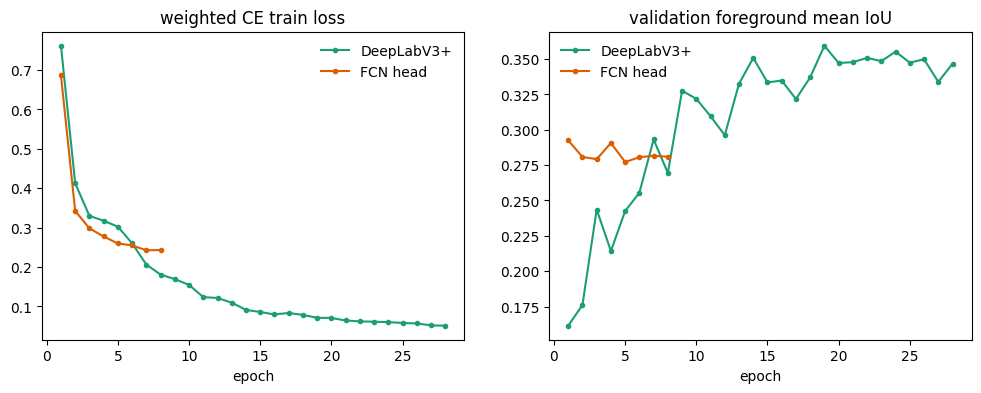

In [18]:
# Full validation pass for both contenders: confusion matrices, then
# per-class IoU and Dice pulled from the crosstab margins, then the
# learning curves side by side.
tab_a = crosstab_confusion(model_a, val_loader)
tab_b = crosstab_confusion(model_b, val_loader)
report_a = scores_from_crosstab(tab_a)
report_b = scores_from_crosstab(tab_b)

named = lambda t: t.rename(index=dict(enumerate(CLASS_NAMES)),
                           columns=dict(enumerate(CLASS_NAMES)))
print("confusion - DeepLabV3+ (rows actual, columns predicted)")
print(named(tab_a).to_string())
print()
print("confusion - FCN head-tuned")
print(named(tab_b).to_string())
print()
both = report_a.merge(report_b, on="class",
                      suffixes=(" [DLv3+]", " [FCN]"))
print("per-class validation scores")
print(both.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for hist, name, ci in ((hist_a, "DeepLabV3+", 0), (hist_b, "FCN head", 1)):
    eps  = [h[0] for h in hist]
    loss = [h[1] for h in hist]
    miou = [h[2] for h in hist]
    axes[0].plot(eps, loss, marker=".", color=plt.cm.Dark2(ci), label=name)
    axes[1].plot(eps, miou, marker=".", color=plt.cm.Dark2(ci), label=name)
axes[0].set_title("weighted CE train loss")
axes[1].set_title("validation foreground mean IoU")
for ax in axes:
    ax.set_xlabel("epoch")
    ax.legend(frameon=False)
plt.show()

            model  mean_IoU_all  mean_IoU_fg  mean_Dice_all  mean_Dice_fg  IoU_background  IoU_person  IoU_car  IoU_book  IoU_airplane  Dice_background  Dice_person  Dice_car  Dice_book  Dice_airplane
deeplabv3plus_r50        0.4789       0.3595         0.5809        0.4817          0.9564      0.5698   0.6247    0.1489        0.0945           0.9777       0.7260    0.7690     0.2592         0.1727
fcn_r50_head_only        0.4256       0.2926         0.4910        0.3692          0.9578      0.5774   0.5930    0.0000        0.0000           0.9784       0.7321    0.7445     0.0000         0.0000

higher foreground mean IoU: deeplabv3plus_r50


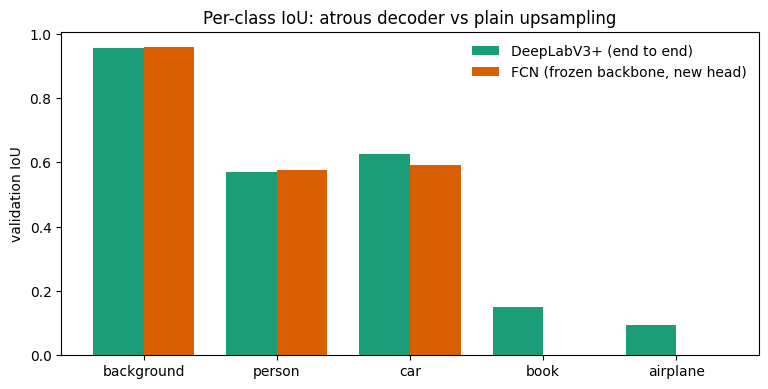

In [19]:
# Benchmark summary: per-class and mean IoU / Dice for both models, saved
# to dlv3plus_bench/summary.csv, plus a grouped bar chart of per-class IoU
# that makes the atrous-vs-plain gap directly readable.
def summarize(name, rep):
    iou = rep["IoU"].to_numpy()
    dice = rep["Dice"].to_numpy()
    row = {"model": name,
           "mean_IoU_all": float(np.nanmean(iou)),
           "mean_IoU_fg": float(np.nanmean(iou[1:])),
           "mean_Dice_all": float(np.nanmean(dice)),
           "mean_Dice_fg": float(np.nanmean(dice[1:]))}
    row.update({f"IoU_{n}": float(v) for n, v in zip(CLASS_NAMES, iou)})
    row.update({f"Dice_{n}": float(v) for n, v in zip(CLASS_NAMES, dice)})
    return row

summary = pd.DataFrame([summarize("deeplabv3plus_r50", report_a),
                        summarize("fcn_r50_head_only", report_b)])
summary.to_csv(OUT_DIR / "summary.csv", index=False)
print(summary.round(4).to_string(index=False))
lead = summary.loc[summary["mean_IoU_fg"].idxmax(), "model"]
print(f"\nhigher foreground mean IoU: {lead}")

width = 0.38
xpos = np.arange(NUM_CLASSES)
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(xpos - width / 2, report_a["IoU"], width,
       color=plt.cm.Dark2(0), label="DeepLabV3+ (end to end)")
ax.bar(xpos + width / 2, report_b["IoU"], width,
       color=plt.cm.Dark2(1), label="FCN (frozen backbone, new head)")
ax.set_xticks(xpos)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel("validation IoU")
ax.set_title("Per-class IoU: atrous decoder vs plain upsampling")
ax.legend(frameon=False)
plt.show()

## 10 | Test Gallery

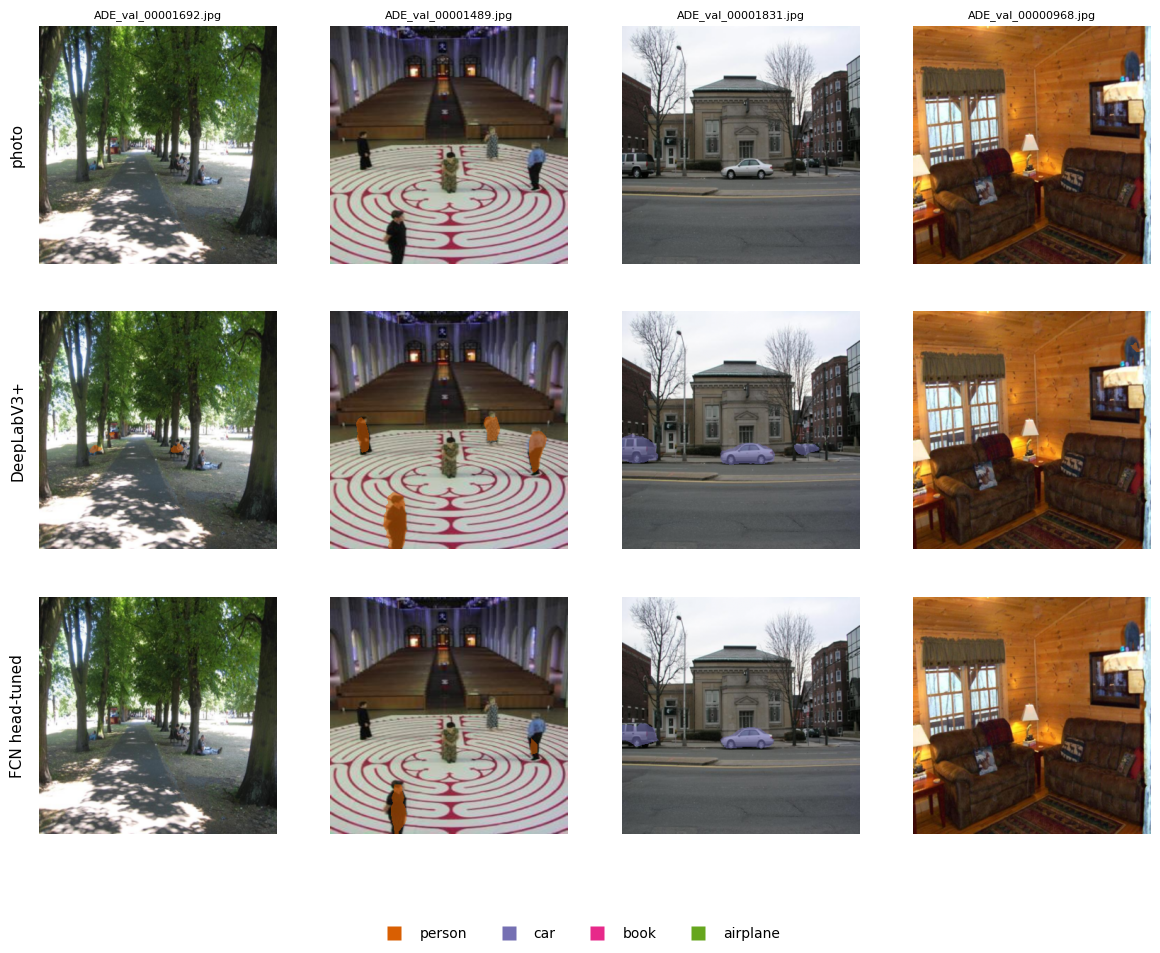

In [20]:
# Qualitative sanity check on held-out test photos, which carry no labels:
# the same FramePrep preprocessing feeds both networks and their argmax
# maps are tinted over the photo for a direct visual comparison.
rng = np.random.default_rng(SEED + 1)
n_show = min(4, len(test_images))
gallery = [test_images[int(i)]
           for i in rng.choice(len(test_images), size=n_show, replace=False)]

def predict_labels(model, pil_img):
    model.eval()
    x = prep.prep_image(pil_img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        return logits_of(model, x).argmax(1)[0].cpu().numpy().astype(np.uint8)

fig, axes = plt.subplots(3, n_show, figsize=(3.6 * n_show, 10.5))
for col, path in enumerate(gallery):
    pil_img = Image.open(path).convert("RGB")
    base = np.asarray(pil_img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR))
    axes[0, col].imshow(base)
    axes[0, col].set_title(path.name, fontsize=8)
    axes[1, col].imshow(tint(base, predict_labels(model_a, pil_img)))
    axes[2, col].imshow(tint(base, predict_labels(model_b, pil_img)))
    for r in range(3):
        axes[r, col].axis("off")
for r, name in enumerate(["photo", "DeepLabV3+", "FCN head-tuned"]):
    axes[r, 0].text(-0.06, 0.5, name, transform=axes[r, 0].transAxes,
                    rotation=90, ha="right", va="center", fontsize=11)
handles = [Line2D([0], [0], marker="s", linestyle="", markersize=10,
                  markerfacecolor=CLASS_COLORS[l][:3], markeredgecolor="none",
                  label=CLASS_NAMES[l]) for l in range(1, NUM_CLASSES)]
fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False)
plt.show()